In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

In [4]:
# 1. Load Dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Normalize (0–255 → 0–1)
train_images = train_images / 255.0
test_images = test_images / 255.0

In [5]:
# 2. Class Names (for reference)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [9]:
# 3. Build CNN Model

model = models.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(64, (3,3), activation='relu'),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [10]:
# 4. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# 5. Train Model
history = model.fit(
    train_images, train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4559 - loss: 1.4972 - val_accuracy: 0.5474 - val_loss: 1.2487
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.5959 - loss: 1.1433 - val_accuracy: 0.6220 - val_loss: 1.0604
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.6494 - loss: 0.9952 - val_accuracy: 0.6628 - val_loss: 0.9660
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6817 - loss: 0.8978 - val_accuracy: 0.6726 - val_loss: 0.9485
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7130 - loss: 0.8259 - val_accuracy: 0.6658 - val_loss: 0.9549


In [13]:
# 6. Evaluate Model
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6658 - loss: 0.9549
Test Accuracy: 0.6657999753952026


In [14]:
# 7. Prediction
import numpy as np

sample = test_images[0:1]
prediction = model.predict(sample)

print("Predicted:", class_names[np.argmax(prediction)])
print("Actual   :", class_names[int(test_labels[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Predicted: cat
Actual   : cat


/tmp/ipykernel_969/2622168916.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Actual   :", class_names[int(test_labels[0])])


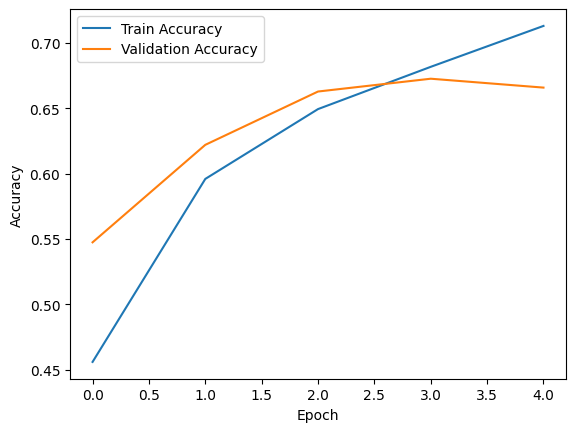

In [15]:
# 8. Plot Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()